# Putative Genetic Load
Given that the tara iti reference genome could not be annotated with RNA sequencing, ensure a robust and conservative assessment of genetic load that is translatable across species comparisons, we limited load estimates to highly conserved BUSCO genes in the fairy tern species complex (*Sterna nereis* spp.) and kakī (*Himantopus novazealandiae*) for comparison.  

To start, we ran BUSCO v5.4.7 for the tara iti and kakī reference genome.  

In [ ]:
busco --in Katie_racon_ragtag_autosomes.fa --out busco/ --mode genome --lineage_dataset aves_odb10 --cpu 32
busco --in himNova-hic-scaff_autosomes.fa --out busco/ --mode genome --lineage_dataset aves_odb10 --cpu 32

We then concatenated single copy BUSCO sequences into species specific `GFF` files.  

In [ ]:
cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.gff > SIFT_DB/TI_annotation/merged_scBUSCOs.gff
cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.gff > SIFT_DB/KI_annotation/merged_scBUSCOs.gff

cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.faa > SIFT_DB/TI_annotation/merged_scBUSCOs.fa
cat busco/run_aves_odb10/busco_sequences/single_copy_busco_sequences/*.faa > SIFT_DB/KI_annotation/merged_scBUSCOs.fa

We opted to convert the `GFF` files output from BUSCO to `GTF` with [agat](https://github.com/NBISweden/AGAT) v. 1.0.0. First we fixed the concatenated `GFF` from BUSCO to be more compatible with Ensemble's Variant Effect Predictor (VEP).  

In [ ]:
agat_sp_manage_IDs.pl --gff KI_annotations/merged_scBUSCO.gff -o KI_annotations/merged_scBUSCO_checked.gff
agat_sp_manage_IDs.pl --gff TI_annotations/merged_scBUSCO.gff -o TI_annotations/merged_scBUSCO_checked.gff

This `GFF` was then converted to `GTF` with AGAT and errors in coordinates (where the end position is before the start position) were corrected before sorting, file compression with `bgzip` and indexing with `tabix`.  130 records in the TI genome and 55 records in the kaki genome had ending positions that occurred before the start positions. These start/end positions were flipped in order to not crash VEP.  

In [ ]:
agat_convert_sp_gff2gtf.pl --gff KI_annotations/merged_scBUSCO_checked.gff -o KI_annotations/merged_scBUSCO_checked.gtf
agat_convert_sp_gff2gtf.pl --gff TI_annotations/merged_scBUSCO_checked.gff -o TI_annotations/merged_scBUSCO_checked.gtf

cat KI_annotations/merged_scBUSCO_checked.gtf | \
    awk '{ if ($5<$4) print $1"\t"$2"\t"$3"\t"$5"\t"$4"\t"$6"\t"$7"\t"$8"\t"$9"\t"$10"\t"$11"\t"$12"\t"$13"\t"$14,$15,$16,$17,$18,$19,$20,$21,$22; else print $0}' | \
    sort -k1,1 -k4,4n -k5,5n -t$'\t' | bgzip -c > KI_annotations/scBUSCO_coordinates_fixed.gtf.gz
cat TI_annotations/merged_scBUSCO_checked.gtf | \
    awk '{ if ($5<$4) print $1"\t"$2"\t"$3"\t"$5"\t"$4"\t"$6"\t"$7"\t"$8"\t"$9"\t"$10"\t"$11"\t"$12"\t"$13"\t"$14,$15,$16,$17,$18,$19,$20,$21,$22; else print $0}' | \
    sort -k1,1 -k4,4n -k5,5n -t$'\t' | bgzip -c > TI_annotations/scBUSCO_coordinates_fixed.gtf.gz

tabix -p gff KI_annotations/scBUSCO_coorinates_fixed.gtf.gz
tabix -p gff TI_annotations/scBUSCO_coorinates_fixed.gtf.gz

The sum of sc-BUSCO gene regions is 289,743,567bp in kakī and 227,780,539bp in tara iti. This corresponds to roughly 26% and 21% of the kakī and fairy tern genomes. 

### Sites Polarised with ANGSD
To estimate masked and realised load in each fairy tern population and kakī we used ANGSD to output the major minor alleles, the called genotype, the posterior probability of the called genotype and all possible genotypes (`-doGeno 31`) to a BCF file (`-doBcf 1`).  

In [ ]:
angsd -P 24 -b ${ANGSD}GLOBAL.list -ref ${TREF} -anc ${TANC} -out ${ANGSD}samtools/genotypes/GLOBAL_polarized \
        -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 -skipTriallelic 1 \
        -minMapQ 20 -minQ 20 -minInd 57 -setMinDepth 555 -setMaxDepth 1056 -doCounts 1 \
        -doPost 1 -postCutoff 0.95 -doBcf 1 -GL 1 -doMajorMinor 5 -doMaf 1 -SNP_pval 1e-6 -doGeno 31 --ignore-RG 0

angsd -P 32 -b ${DIR}KI.list -ref ${KREF} -anc ${KANC} -out ${DIR}samtools/genotypes/KI_polarized \
        -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 -skipTriallelic 1 \
        -minMapQ 20 -minQ 20 -minInd 24 -setMinDepth 700 -maxDepth 1200 -doCounts 1 \
        -doPost 1 -postCutoff 0.95 -doBcf 1 -GL 1 -doMajorMinor 5 -doMaf 1 -SNP_pval 1e-6 -doGeno 31 --ignore-RG 0


### Variant Effect Predictor
Ensemble's [Variant Effect Predictor](https://www.ensembl.org/info/docs/tools/vep/vep_formats.html#output) (VEP) is a tool for analyzing tool for inferring the coding consequences of sequence variation. VEP was run below using the GTF files constructed above.  

In [ ]:
vep -i GLOBAL_variable_alt.vcf \
    --gtf TI_annotations/scBUSCO_checked_coordinate_corrected.gtf.gz \
    --fasta Katie_autosomes.fa \
    -o vep_data/angsd_high_confidence_BUSCO_SNPs/GLOBAL_whole-genome_polarized

vep -i KI_variable_alt.vcf \
    --gtf KI_annotation/scBUSCO_checked_coordinate_corrected.gtf.gz \
    --fasta references/kaki_autosomes.fa \
    -o vep_data/angsd_high_confidence_BUSCO_SNPs/KI_whole-genome_polarized

VEP identifies the type of mutation and assigns a level of 'severity' to the mutation. This ranges from high, moderate, low, and modifier. A summary of each is in the table below. 

| Consequence |     Definition     |
|:-----------:|:------------------:|
|     Low     | Assumed to be mostly harmless or unlikely to change protein behaviour.  | 
|   Moderate  | A non-disruptive variant that might change protein effectiveness. |
|     High    | The variant is assumed to have high impact on the protein, probably causing truncation, loss of function, or triggering nonsense mediated decay. |
|   Modifier  | Usually non-coding variants or variants affecting non-codeing genes, where predictions are difficult or there is no evidence of impact. |

Given that the 'Modifier' consequence is assigned to mutations where predictions are difficult or there is a lack of evidence, the only mutations assigned as modifiers that were retained were intergenic variants. These are used later in our estimates of R<sub>*XY*</sub>.  

Below we count the number of alleles of each consequence for tara iti, Australian fairy tern. This loop was modified and run for kakī in the same manner.  

In [ ]:
while read -r line
    do
    POSIT=$(echo $line | awk '{print $1}')
    AALLE=$(bcftools query -t ${POSIT} -f '[%GT\n]' GLOBAL_variable_alt_AU.bcf | sed 's%0/0%0%g' | sed 's%0/1%1%g'| sed 's%1/1%2%g' | awk '{sum += $1}; END {print sum}')
    TALLE=$(bcftools query -t ${POSIT} -f '[%GT\n]' GLOBAL_variable_alt_TI.bcf | sed 's%0/0%0%g' | sed 's%0/1%1%g'| sed 's%1/1%2%g' | awk '{sum += $1}; END {print sum}')
    printf "$line\t$AALLE\tAU\n" >> pop_allele_frequency.tsv
    printf "$line\t$TALLE\tNZ\n" >> pop_allele_frequency.tsv
    echo $line
done < fairy_alleles.txt

However, there were roughly 134 and XXX sites in the fairy tern and kakī data sets that had ambiguous mutation types and consequences, that is to say the same site had multiple mutation types and consequences. These sites were excluded from all downstream analyses to ensure a conservative estimate of putative mutation load.  

In [ ]:
sort fairy_harmful_allele.txt | uniq | \
    cut -f1 | \
    sort | \
    uniq -c | \
    awk '{if ($1>1) print $2}' > fairy_exclude.tsv

sort kaki_harmful_allele.txt | uniq | \
    cut -f1 | \
    sort | \
    uniq -c | \
    awk '{if ($1>1) print $2}' > kaki_exclude.tsv

Then we counted the number of alleles per site, per individual for all derived alleles and their consequences as inferred by VEP.  

In [ ]:
while read -r line
    do
    POSIT=$(echo $line | awk '{print $1}')
    MUTAT=$(echo $line | awk '{print $2}')
    EFFECT=$(echo $line | awk '{print $3}')
    echo "$line"
    if [[ "$EFFECT" == "LOW" ]]; then
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tLow\n]' GLOBAL_variable_alt_AU.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tLow\n]' GLOBAL_variable_alt_TI.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
    elif [[ "$EFFECT" == "MODERATE" ]]; then
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tModerate]' GLOBAL_variable_alt_AU.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tModerate]' GLOBAL_variable_alt_TI.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
    elif [[ "$EFFECT" == "HIGH" ]]; then
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tHigh]' GLOBAL_variable_alt_AU.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tHigh]' GLOBAL_variable_alt_TI.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
    else
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tAU\tModifier]' GLOBAL_variable_alt_AU.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
        bcftools query -t ${POSIT} -f '[%CHROM\t%POS\t$SAMPLE\t%GT\tTI\tModifier]' GLOBAL_variable_alt_TI.vcf | awk -v VAR="$MUTAT" '{print $0"\t"VAR}' >> indiv_harmful_allele_frequency.tsv
    fi
done < fairy_alleles.txt

## Load Estimates
### Harmful allele frequency


In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import linregress
from sklearn.metrics import r2_score
from scipy.stats import mannwhitneyu
from scipy import stats

#path = '/nesi/nobackup/uc03718/'
#os.chdir(path)
print(os.getcwd())

c:\Users\jwold\GitHub\2026_S_nereis_Cons_Gen


In [5]:
indiv_vep = pd.read_csv('indiv_allele_freq.tsv', sep='\t', names=['Chromosome', 'Position', 'Sample', 'Genotype', 'Population'])

consequence = pd. read_csv('fairy_vep_simple.txt', sep='\t', names=['Chromosome', 'Mutation Class', 'Consequence'])
consequence[['Chromosome', 'Position']] = consequence['Chromosome'].str.split(':', expand=True)

# Handle ambiguous sites where multiple different mutation types and consequences were called
consistent = (
    consequence.groupby(['Chromosome', 'Position'])
    .filter(lambda g: (g['Mutation Class'].nunique() == 1) and (g['Consequence'].nunique() == 1))
)

# Drop remaining duplicate sites
consistent = consistent.drop_duplicates()

# Making sure that Position is the correct dat type before progressing
consistent['Position'] = consistent['Position'].astype(int)
indiv_vep['Position'] = indiv_vep['Position'].astype(int)

# And now add Mutation type and Consequence
indiv_vep = pd.merge(indiv_vep, consistent, on=['Chromosome', 'Position'], how='inner')

# Now changing genotypes to allele counts
replace_map = {
    '0/0': 0,
    '0/1': 1,
    '1/1': 2
}

indiv_vep['Allele Count'] = indiv_vep['Genotype'].replace(replace_map)
indiv_vep = indiv_vep.drop(columns=['Genotype'])

C:\Users\jwold\AppData\Local\Temp\ipykernel_28804\266805531.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  indiv_vep['Allele Count'] = indiv_vep['Genotype'].replace(replace_map)


Double checking that ambiguous sites have been excluded. 

In [6]:
dupes = indiv_vep[indiv_vep.duplicated(subset=['Chromosome', 'Position', 'Population', 'Sample'], keep=False)]

print(len(dupes), len(indiv_vep))

0 32550306


In [7]:
conditions = [
    indiv_vep['Allele Count'] == 0,
    indiv_vep['Allele Count'] == 1,
    indiv_vep['Allele Count'] == 2
]

categories = ['Hom Ref', 'Het', 'Hom Alt']

indiv_vep['Genotype Category'] = np.select(conditions, categories, default='Unknown')

indiv_vep.head()

,Chromosome,Position,Sample,Population,Mutation Class,Consequence,Allele Count,Genotype Category
0,CM020437.1_RagTag,321977,AU01,AU,intergenic_variant,MODIFIER,1,Het
1,CM020437.1_RagTag,321977,AU03,AU,intergenic_variant,MODIFIER,0,Hom Ref
2,CM020437.1_RagTag,321977,AU04,AU,intergenic_variant,MODIFIER,0,Hom Ref
3,CM020437.1_RagTag,321977,AU06,AU,intergenic_variant,MODIFIER,0,Hom Ref
4,CM020437.1_RagTag,321977,AU08,AU,intergenic_variant,MODIFIER,0,Hom Ref


We have 0 dupes, so are good to progress to aggregating the individual counts into population counts.  

In [8]:
pop_vep = indiv_vep.groupby(['Chromosome', 'Position', 'Population'], as_index=False).agg({
    'Allele Count': 'sum',
    'Mutation Class': 'first',
    'Consequence': 'first'
})

# And now estimating allele frequency 
conditions = [
    pop_vep['Population']=='AU',
    pop_vep['Population']=='NZ',
    pop_vep['Population']=='KI'
]

denominators = [2*19, 2*38, 2*24] # Double the population size for each

pop_vep['Allele Frequency'] = pop_vep['Allele Count'] / np.select(conditions, denominators, default=np.nan)

pop_vep.head()

,Chromosome,Position,Population,Allele Count,Mutation Class,Consequence,Allele Frequency
0,CM020437.1_RagTag,321977,AU,1,intergenic_variant,MODIFIER,0.026316
1,CM020437.1_RagTag,321977,NZ,0,intergenic_variant,MODIFIER,0.000000
2,CM020437.1_RagTag,322008,AU,1,intergenic_variant,MODIFIER,0.026316
3,CM020437.1_RagTag,322008,NZ,1,intergenic_variant,MODIFIER,0.013158
4,CM020437.1_RagTag,638279,AU,1,intergenic_variant,MODIFIER,0.026316


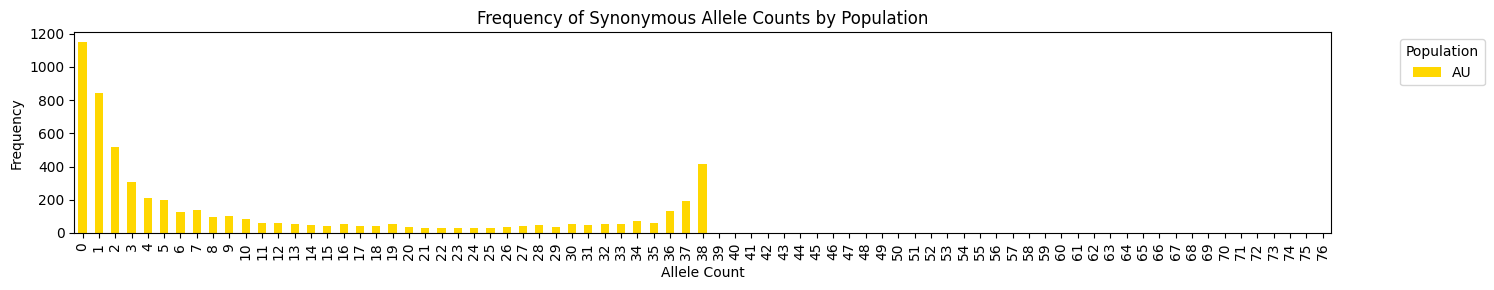

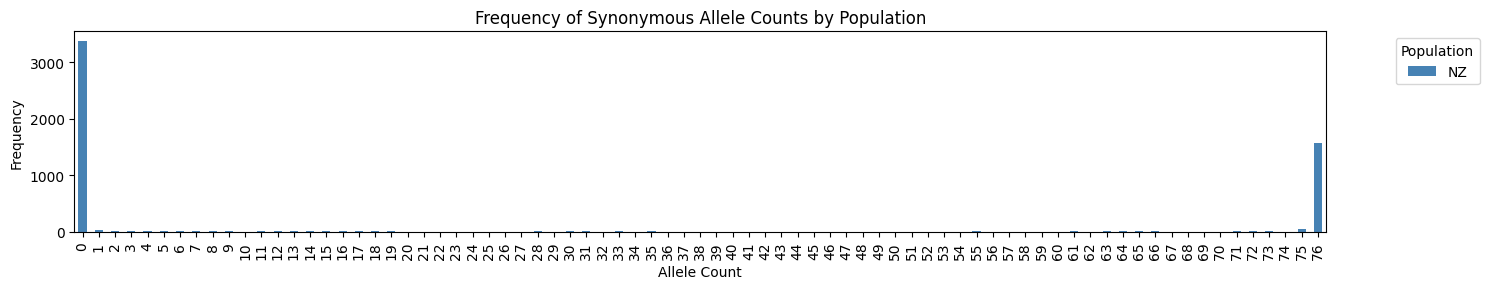

In [10]:
synonymous_count = pop_vep[pop_vep['Mutation Class']=='synonymous_variant']

au_counts = synonymous_count[synonymous_count['Population']=='AU'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ti_counts = synonymous_count[synonymous_count['Population']=='NZ'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
#ki_LowCounts = count_vep[count_vep['Population']=='KI'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

plot_range = range(0, ti_counts['Allele Count'].max() + 1)

au_pivot = au_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
ti_pivot = ti_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
#ki_pivot = ki_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)

# Plot a stacked bar chart
au_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="gold")
plt.title("Frequency of Synonymous Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

ti_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="steelblue")
plt.title("Frequency of Synonymous Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

#ki_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="black")
plt.title("Frequency of Synonymous Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

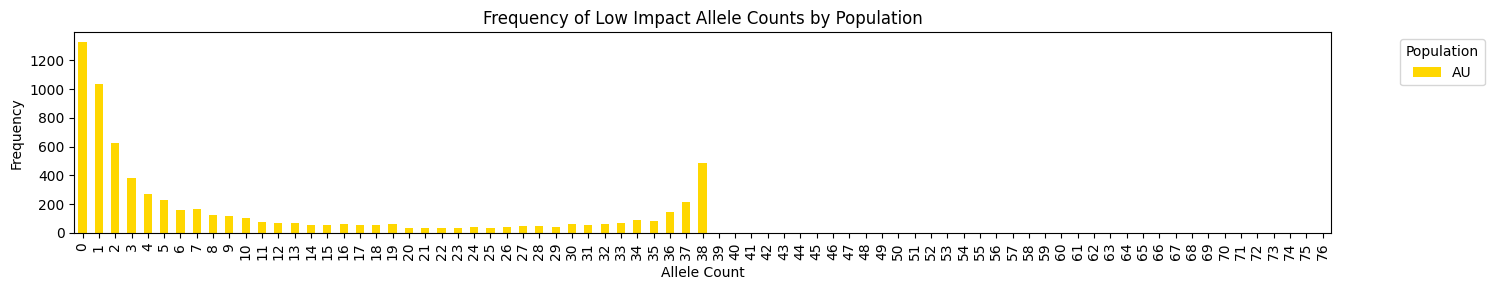

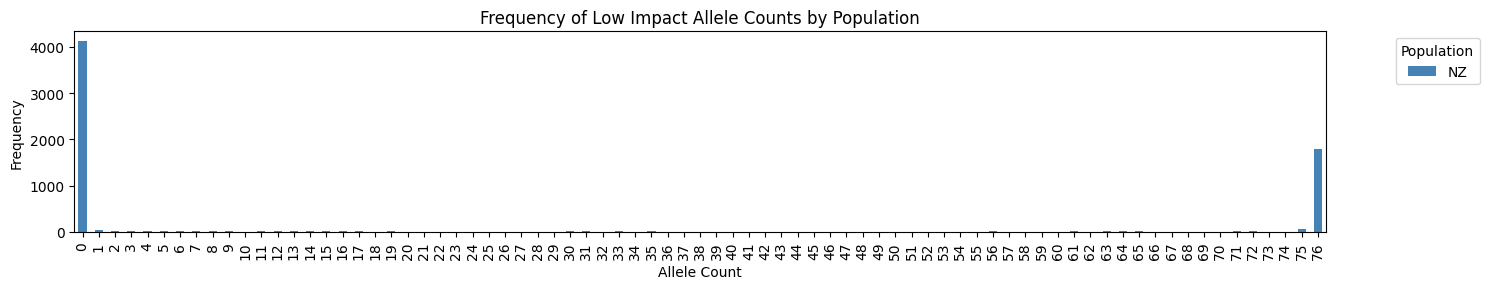

In [129]:
#count_vep = pop_vep[pop_vep['Allele Count']>0]
count_vep = pop_vep
intergenic_count = count_vep[count_vep['Mutation Class']=='intergenic_variant']

au_LowCounts = count_vep[(count_vep['Population']=='AU') & (count_vep['Consequence']=='LOW')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ti_LowCounts = count_vep[(count_vep['Population']=='NZ') & (count_vep['Consequence']=='LOW')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
#ki_LowCounts = count_vep[count_vep['Population']=='KI'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

plot_range = range(0, ti_LowCounts['Allele Count'].max() + 1)

au_pivot = au_LowCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
ti_pivot = ti_LowCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
#ki_pivot = ki_LowCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)

# Plot a stacked bar chart
au_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="gold")
plt.title("Frequency of Low Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

ti_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="steelblue")
plt.title("Frequency of Low Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

#ki_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="black")
plt.title("Frequency of Low Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

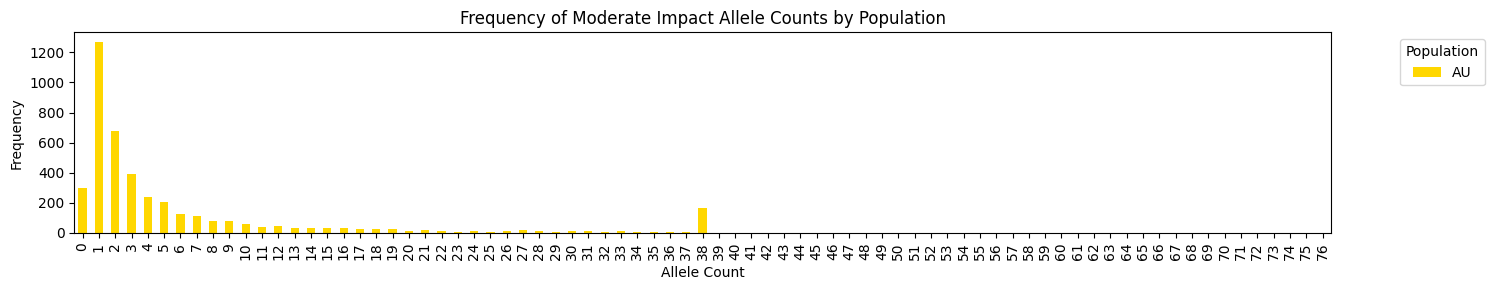

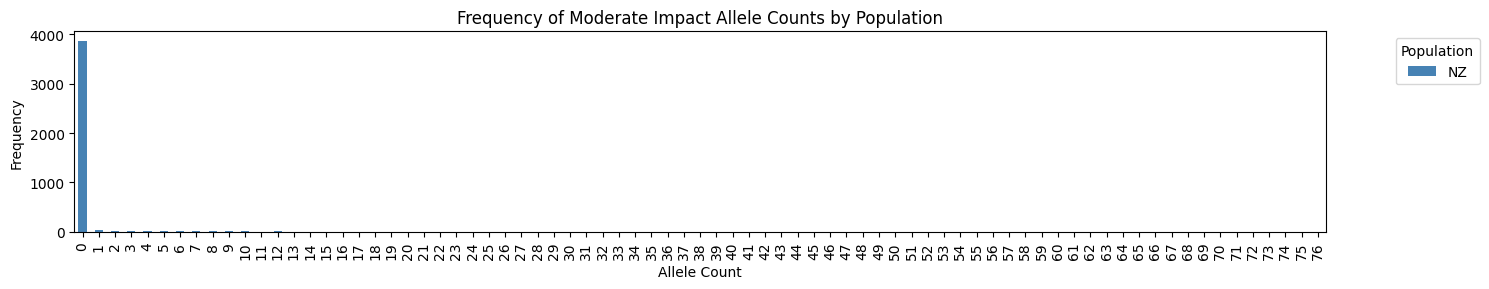

In [131]:
#count_vep = pop_vep[pop_vep['Allele Count']>0]
count_vep = pop_vep
intergenic_count = count_vep[count_vep['Mutation Class']=='intergenic_variant']

au_counts = count_vep[(count_vep['Population']=='AU') & (count_vep['Consequence']=='MODERATE')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ti_counts = count_vep[(count_vep['Population']=='NZ') & (count_vep['Consequence']=='MODERATE')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
#ki_counts = count_vep[(count_vep['Population']=='KI') & (count_vep['Consequence]=='MODERATE')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

plot_range = range(0, ti_LowCounts['Allele Count'].max() + 1)

au_pivot = au_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
ti_pivot = ti_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
#ki_pivot = ki_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)

# Plot a stacked bar chart
au_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="gold")
plt.title("Frequency of Moderate Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

ti_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="steelblue")
plt.title("Frequency of Moderate Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

#ki_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="black")
plt.title("Frequency of Moderate Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

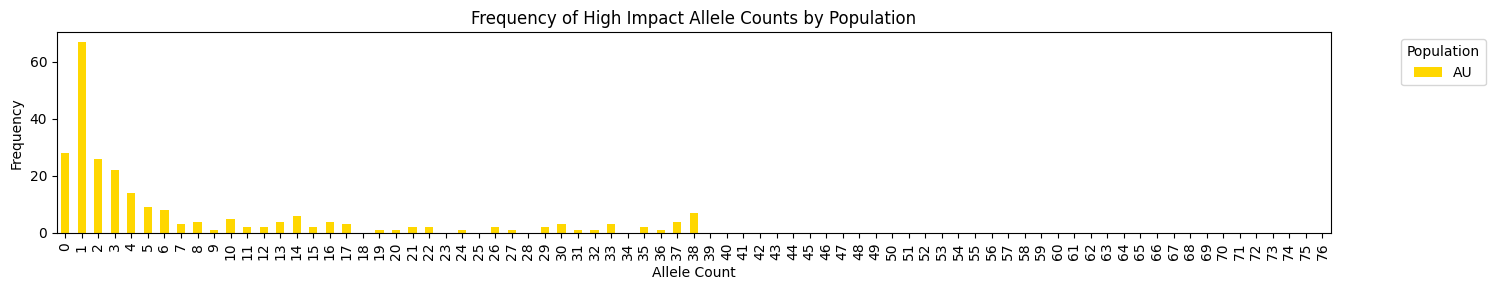

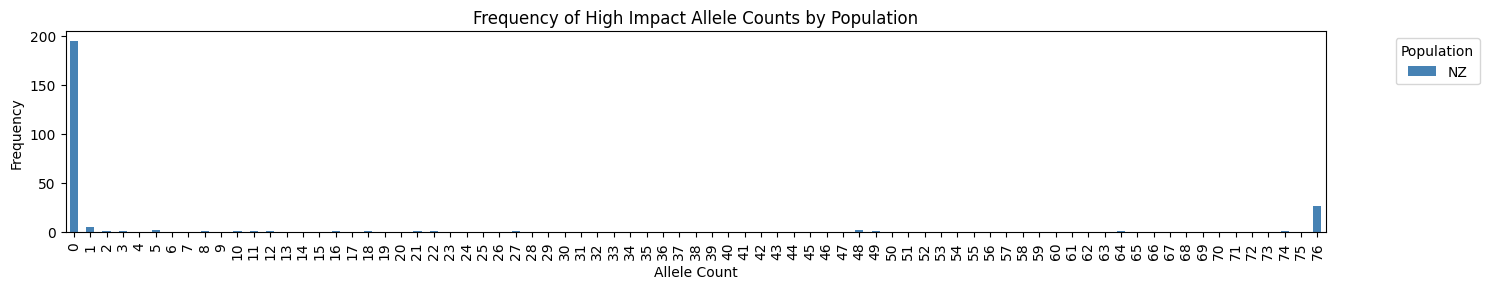

In [132]:
#count_vep = pop_vep[pop_vep['Allele Count']>0]
count_vep = pop_vep
intergenic_count = count_vep[count_vep['Mutation Class']=='intergenic_variant']

au_counts = count_vep[(count_vep['Population']=='AU') & (count_vep['Consequence']=='HIGH')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ti_counts = count_vep[(count_vep['Population']=='NZ') & (count_vep['Consequence']=='HIGH')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
#ki_counts = count_vep[(count_vep['Population']=='KI') & (count_vep['Consequence]=='HIGH')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

plot_range = range(0, ti_LowCounts['Allele Count'].max() + 1)

au_pivot = au_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
ti_pivot = ti_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)
#ki_pivot = ki_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(plot_range, fill_value=0)

# Plot a stacked bar chart
au_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="gold")
plt.title("Frequency of High Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

ti_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="steelblue")
plt.title("Frequency of High Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

#ki_pivot.plot(kind="bar", stacked=True, figsize=(15, 3), color="black")
plt.title("Frequency of High Impact Allele Counts by Population")
plt.ylabel("Frequency")
plt.xlabel("Allele Count")
plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

In [11]:
print('The mean allele frequency of putatively harmful alleles in AFT: ', pop_vep[(pop_vep['Population']=='AU') & (pop_vep['Consequence']!='MODIFIER') & (pop_vep['Consequence']!='LOW')]['Allele Frequency'].mean())
print('The mean allele frequency of putatively harmful alleles in TI:  ', pop_vep[(pop_vep['Population']=='NZ') & (pop_vep['Consequence']!='MODIFIER') & (pop_vep['Consequence']!='LOW')]['Allele Frequency'].mean())
#print('The mean allele frequency of putatively harmful alleles in KI:  ', pop_vep[(pop_vep['Population']=='KI') & (pop_vep['Consequence']!='MODIFIER') & (pop_vep['Consequence']!='LOW')]['Allele Frequency'].mean())

The mean allele frequency of putatively harmful alleles in AFT:  0.15963923337091318
The mean allele frequency of putatively harmful alleles in TI:   0.021005162285646473


Text(0.5, 1.0, 'Number of Sites Variable in Each Population')

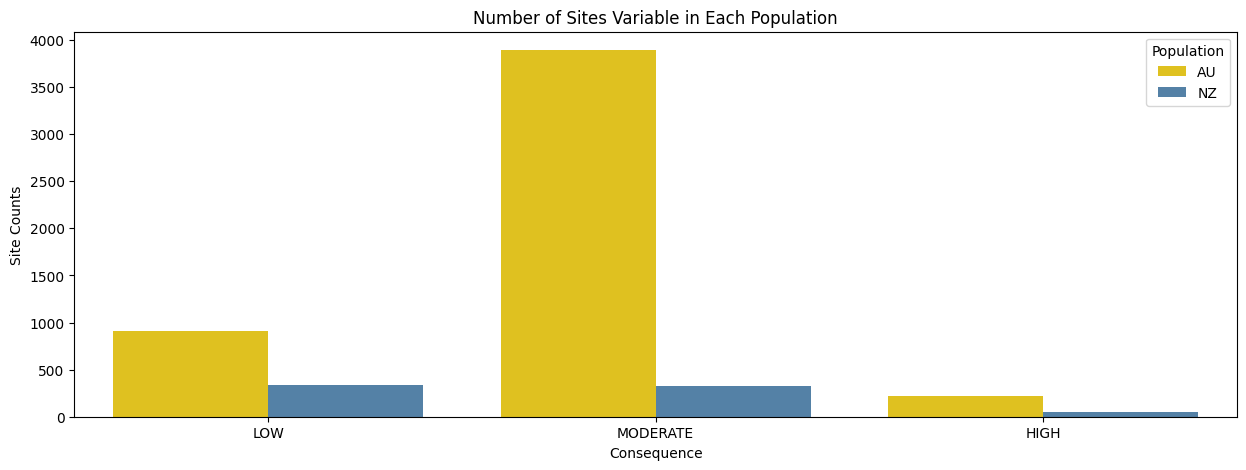

In [12]:
plt.figure(figsize=(15,5))

nonzero_counts = pop_vep[(pop_vep['Consequence']!='MODIFIER') & (pop_vep['Mutation Class']!='synonymous_variant') & (pop_vep['Allele Count']>0)].groupby(['Population', 'Consequence']).size().reset_index(name='Site Counts')

sns.barplot(data=nonzero_counts, x='Consequence', y='Site Counts', hue='Population', hue_order=['AU', 'NZ'], palette={'AU': 'gold', 'NZ': 'steelblue'}, order=['LOW', 'MODERATE', 'HIGH'])
plt.title('Number of Sites Variable in Each Population')


We then estimated R<sub>xy</sub> between each of the three populations for putatively intolerant, tolerant, and all synonymous mutations. The [code](https://github.com/samarth8392/MQU_EvoGenomics/blob/main/RScripts/Rxy.R) below was adapted from [Mathur et al (2023)](http://doi.org/10.1093/evolut/qpac061).  

In [13]:
def estimate_rxy(df, pop1, pop2, consequence, chroms_df):
    # Separate deleterious and synonymous data based on consequence type
    del_df = df[(df['Consequence'] == consequence)]
    syn_df = df[df['Mutation Class'] == 'synonymous_variant']

    # Merge data for both populations
    del_merged = pd.merge(del_df[del_df['Population'] == pop1], del_df[del_df['Population'] == pop2],
                          on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))
    
    syn_merged = pd.merge(syn_df[syn_df['Population'] == pop1], syn_df[syn_df['Population'] == pop2],
                          on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))

    # Calculate l_xy and l_yx
    l_xy = np.sum(del_merged["Allele Frequency_pop1"] * (1 - del_merged["Allele Frequency_pop2"])) / np.sum(syn_merged["Allele Frequency_pop1"] * (1 - syn_merged["Allele Frequency_pop2"]))
    l_yx = np.sum(del_merged["Allele Frequency_pop2"] * (1 - del_merged["Allele Frequency_pop1"])) / np.sum(syn_merged["Allele Frequency_pop2"] * (1 - syn_merged["Allele Frequency_pop1"]))
    
    # Initialize results list
    Rxy_results = []

    # Loop over chromosomes
    for chr in chroms_df['Chromosome']:
        # Filter data excluding one chromosome at a time
        del_df_excluded = del_df[(del_df['Chromosome'] != chr)]
        syn_df_excluded = syn_df[(syn_df['Chromosome'] != chr)]

        # Merge excluded data for both populations
        del_excluded_merged = pd.merge(del_df_excluded[del_df_excluded['Population'] == pop1],
                                      del_df_excluded[del_df_excluded['Population'] == pop2],
                                      on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))
        
        syn_excluded_merged = pd.merge(syn_df_excluded[syn_df_excluded['Population'] == pop1],
                                      syn_df_excluded[syn_df_excluded['Population'] == pop2],
                                      on=['Chromosome', 'Position'], suffixes=('_pop1', '_pop2'))

        # Calculate l_xy_excluded and l_yx_excluded
        l_xy_excluded = np.sum(del_excluded_merged["Allele Frequency_pop1"] * (1 - del_excluded_merged["Allele Frequency_pop2"])) / np.sum(syn_excluded_merged["Allele Frequency_pop1"] * (1 - syn_excluded_merged["Allele Frequency_pop2"]))
        l_yx_excluded = np.sum(del_excluded_merged["Allele Frequency_pop2"] * (1 - del_excluded_merged["Allele Frequency_pop1"])) / np.sum(syn_excluded_merged["Allele Frequency_pop2"] * (1 - syn_excluded_merged["Allele Frequency_pop1"]))

        # Calculate rxy_excluded
        rxy_excluded = l_xy_excluded / l_yx_excluded

        # Append result to list
        Rxy_results.append({'Chromosome Excluded': chr, 'Rxy': rxy_excluded, 'Consequence': consequence})

    # Convert list of dictionaries to DataFrame
    Rxy_results_df = pd.DataFrame(Rxy_results)

    return Rxy_results_df

In [15]:
# Load and process data so we have Allele frequency column
del_pop_allele = pd.read_csv('VEP/pop_harmful_allele_frequency.tsv', delimiter='\t', names=['Chromosome', 'Mutation Class', 'Consequence', 'Allele Count', 'Population'])

del_pop_allele[['Chromosome', 'Position']] = del_pop_allele['Chromosome'].str.split(':', expand=True)

del_pop_allele = del_pop_allele[del_pop_allele['Population']!='KI']
del_pop_allele = del_pop_allele[del_pop_allele['Allele Count']>0]

intergenic = pop_vep[(pop_vep['Mutation Class']=='intergenic_variant') | (pop_vep['Mutation Class']=='synonymous_variant')]
intergenic = intergenic[intergenic['Population']!='KI']
#intergenic = intergenic[intergenic['Allele Count']>0]

chromNames = del_pop_allele['Chromosome'].sort_values().drop_duplicates()
chromNames = pd.DataFrame(chromNames, columns=['Chromosome'])

In [16]:
del_pop_allele.head()

,Chromosome,Mutation Class,Consequence,Allele Count,Population,Position,Allele Frequency
1,CM020437.1_RagTag,synonymous_variant,LOW,5,AU,100153666,0.131579
3,CM020437.1_RagTag,synonymous_variant,LOW,1,AU,100261341,0.026316
5,CM020437.1_RagTag,synonymous_variant,LOW,38,AU,100261455,1.000000
7,CM020437.1_RagTag,missense_variant,MODERATE,3,AU,100262462,0.078947
9,CM020437.1_RagTag,missense_variant,MODERATE,14,NZ,100789127,0.184211


In [21]:
del_Rxy = estimate_rxy(del_pop_allele, 'NZ', 'AU', 'HIGH', chromNames)
tol_Rxy = estimate_rxy(del_pop_allele, 'NZ', 'AU', 'LOW', chromNames)
#neutral_Rxy = estimate_rxy(intergenic, 'NZ', 'AU', 'Intergenic', chromNames)
#Rxy = pd.concat([del_Rxy, tol_Rxy, neutral_Rxy], ignore_index=True)
Rxy_noNeutral = pd.concat([del_Rxy, tol_Rxy], ignore_index=True)

#print("Mean Rxy: ", tol_Rxy['Rxy'].mean(), del_Rxy['Rxy'].mean(), neutral_Rxy['Rxy'].mean())
print("Mean Rxy: ", tol_Rxy['Rxy'].mean(), del_Rxy['Rxy'].mean())

Mean Rxy:  0.9335083751958213 4.421788018371712


## Putatively harmful Allele diversity

Old methods

Now we examine the total number of putatively harmful derived alleles (`Allele Count`), then the number of putatively harmful derived alleles in a 'masked' state (`Het Allele Count`), and finally the number of puatively harmful alleles likely contributing to realised load (`Hom Allele Count`).

In [24]:
indiv_vep.head()

,Chromosome,Position,Sample,Population,Mutation Class,Consequence,Allele Count,Genotype Category
0,CM020437.1_RagTag,321977,AU01,AU,intergenic_variant,MODIFIER,1,Het
1,CM020437.1_RagTag,321977,AU03,AU,intergenic_variant,MODIFIER,0,Hom Ref
2,CM020437.1_RagTag,321977,AU04,AU,intergenic_variant,MODIFIER,0,Hom Ref
3,CM020437.1_RagTag,321977,AU06,AU,intergenic_variant,MODIFIER,0,Hom Ref
4,CM020437.1_RagTag,321977,AU08,AU,intergenic_variant,MODIFIER,0,Hom Ref


In [25]:
allele_counts = indiv_vep[(indiv_vep['Allele Count']>0) & (indiv_vep['Consequence']!='MODIFIER') & (indiv_vep['Mutation Class']!='synonymous_variant')].groupby(['Sample', 'Population', 'Consequence', 'Genotype Category'])['Allele Count'].sum().reset_index()
print(allele_counts)

    Sample Population Consequence Genotype Category  Allele Count
0     AU01         AU        HIGH               Het            42
1     AU01         AU        HIGH           Hom Alt            50
2     AU01         AU         LOW               Het           178
3     AU01         AU         LOW           Hom Alt           390
4     AU01         AU    MODERATE               Het           752
..     ...        ...         ...               ...           ...
337   TI99         NZ        HIGH           Hom Alt            54
338   TI99         NZ         LOW               Het            27
339   TI99         NZ         LOW           Hom Alt           512
340   TI99         NZ    MODERATE               Het            67
341   TI99         NZ    MODERATE           Hom Alt            36

[342 rows x 5 columns]


C:\Users\jwold\AppData\Local\Temp\ipykernel_28804\1002541707.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indiv_vep_filter['Pop-Consequence'] = indiv_vep_filter['Population'] +'-' + indiv_vep_filter['Consequence']
C:\Users\jwold\AppData\Local\Temp\ipykernel_28804\1002541707.py:16: UserWarning: 
The palette list has fewer values (2) than needed (6) and will cycle, which may produce an uninterpretable plot.
  stripplot_0 = sns.stripplot(tot_indiv, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', palette=palette, order=order, jitter=True, size=4, ax=axes[0])
C:\Users\jwold\AppData\Local\Temp\ipykernel_28804\1002541707.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

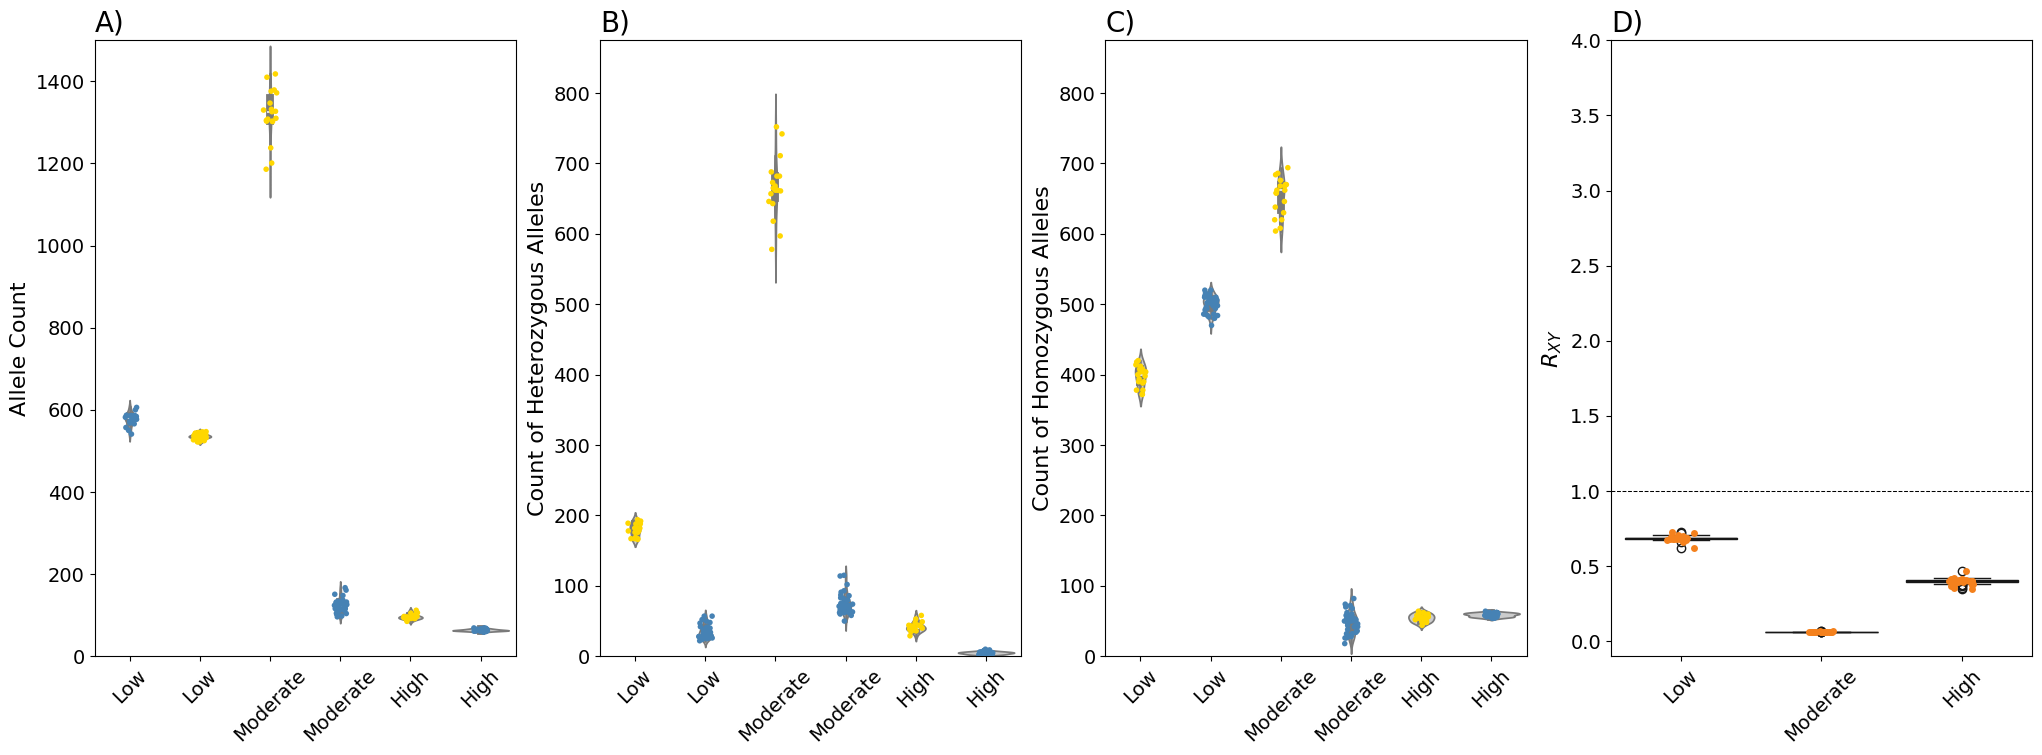

In [ ]:
indiv_vep_filter = indiv_vep[(indiv_vep['Allele Count']>0) & (indiv_vep['Consequence']!='MODIFIER') & (indiv_vep['Mutation Class']!='synonymous_variant')]
indiv_vep_filter['Pop-Consequence'] = indiv_vep_filter['Population'] +'-' + indiv_vep_filter['Consequence']

tot_indiv = indiv_vep_filter.groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()
het_indiv = indiv_vep_filter[indiv_vep_filter['Allele Count']==1].groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()
alt_indiv = indiv_vep_filter[indiv_vep_filter['Allele Count']==2].groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()

combinedRxy = pd.concat([low_Rxy, mod_Rxy, del_Rxy])

palette = ['gold', 'steelblue']
order = ['AU-LOW', 'NZ-LOW', 'AU-MODERATE', 'NZ-MODERATE', 'AU-HIGH', 'NZ-HIGH']

fig, axes = plt.subplots(1, 4, figsize=(25, 8), sharex=False, sharey=False)

sns.violinplot(tot_indiv, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[0])
stripplot_0 = sns.stripplot(tot_indiv, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', palette=palette, order=order, jitter=True, size=4, ax=axes[0])
axes[0].set_title('A)', loc='left', fontsize=20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Allele Count', fontsize=16)
axes[0].set_xticklabels(['Low', 'Low', 'Moderate', 'Moderate', 'High', 'High'], fontsize = 14, rotation=45)
axes[0].tick_params(axis='y', which='major', labelsize=14)
axes[0].set_ylim(0, 1500)

sns.violinplot(het_indiv, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[1])
sns.stripplot(het_indiv, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[1])
axes[1].set_title('B)', loc='left', fontsize=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('Count of Heterozygous Alleles', fontsize=16)
axes[1].set_xticklabels(['Low', 'Low', 'Moderate', 'Moderate', 'High', 'High'], fontsize = 14, rotation=45)
axes[1].tick_params(axis='y', which='major', labelsize=14)
axes[1].set_ylim(0, 875)

sns.violinplot(alt_indiv, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[2])
sns.stripplot(alt_indiv, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[2])
axes[2].set_title('C)', loc='left', fontsize=20)
axes[2].set_xlabel('')
axes[2].set_ylabel('Count of Homozygous Alleles', fontsize=16)
axes[2].set_xticklabels(['Low', 'Low', 'Moderate', 'Moderate', 'High', 'High'], fontsize = 14, rotation=45)
axes[2].tick_params(axis='y', which='major', labelsize=14)
axes[2].set_ylim(0, 875)

sns.boxplot(data=combinedRxy, x='Consequence', y='Rxy', hue='Consequence', color='0.8', ax=axes[3])
sns.stripplot(data=combinedRxy, x='Consequence', y='Rxy', jitter=True, color='#f4811d', dodge=True, ax=axes[3])
axes[3].set_title('D)', loc='left', fontsize=20)
axes[3].set_xlabel('')
axes[3].set_ylabel(r'$R_{XY}$', fontsize=16)
axes[3].set_xticklabels(['Low', 'Moderate', 'High'], fontsize = 14, rotation=45)
axes[3].tick_params(axis='y', which='major', labelsize=14)
axes[3].set_ylim(-0.1, 4)

axes[3].axhline(y=1, color='black', linestyle='--', linewidth=0.75)

plt.savefig('Figures/Figure_6_load_SNP_summary.png', dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.lines as mlines

replace_map = {
    '0/0': 0,
    '0/1': 1,
    '1/1': 2
}

indiv_SVdel = pd.read_csv('indiv_harmful_SVallele_frequency.tsv', delimiter='\t')

indiv_SVdel['Genotype'] = indiv_SVdel['Genotype'].replace(replace_map)
indiv_SVdel['Pop-Consequence'] = indiv_SVdel['Population'] + '-' + indiv_SVdel['State'] 

indiv_SVtotal = indiv_SVdel.groupby(['Sample', 'Population', 'State', 'Pop-Consequence'])['Genotype'].sum().reset_index(name='Allele Count')
indiv_SVhet = indiv_SVdel[indiv_SVdel['Genotype'] == 1]
indiv_SVhet = indiv_SVhet.groupby(['Sample', 'Population', 'State', 'Pop-Consequence'])['Genotype'].sum().reset_index(name='Het Allele Count')
indiv_SVhom = indiv_SVdel[indiv_SVdel['Genotype'] == 2]
indiv_SVhom = indiv_SVhom.groupby(['Sample', 'Population', 'State', 'Pop-Consequence'])['Genotype'].sum().reset_index(name='Hom Allele Count')

indiv_SVtotal.head()

SVallele_prop = pd.merge(indiv_SVtotal, indiv_SVhet, on=['Sample', 'Population', 'State', 'Pop_Consequence'])
SVallele_prop = pd.merge(SVallele_prop, indiv_SVhom, on=['Sample', 'Population', 'State', 'Pop_Consequence'])

SVallele_prop['Het Prop'] = SVallele_prop['Het Allele Count'] / SVallele_prop['Allele Count']
SVallele_prop['Hom Prop'] = SVallele_prop['Hom Allele Count'] / SVallele_prop['Allele Count']

SVallele_prop.head()

palette = ['gold', 'steelblue', 'black']
order = ['AU-Intersecting', 'TI-Intersecting', 'KI-Intersecting', 'AU-Nonintersecting', 'TI-Nonintersecting', 'KI-Nonintersecting']

fig, axes = plt.subplots(1, 4, figsize=(25, 8), sharex=False, sharey=False)

sns.violinplot(SVallele_prop, x='Pop_Consequence', y='Allele Count', order=order, color='0.8', ax=axes[0])
stripplot_0 = sns.stripplot(SVallele_prop, x='Pop_Consequence', y='Allele Count', hue='Pop_Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[0])
axes[0].set_title('E)', loc='left', fontsize=20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Allele Count', fontsize=16)
axes[0].set_xticklabels(['Low', 'Low', 'Low', 'Moderate', 'Moderate', 'Moderate', 'High', 'High', 'High'], fontsize = 14, rotation=45)
axes[0].tick_params(axis='y', which='major', labelsize=14)
axes[0].set_ylim(0, 1000)

sns.violinplot(SVallele_prop, x='Pop_Consequence', y='Het Prop', order=order, color='0.8', ax=axes[1])
sns.stripplot(SVallele_prop, x='Pop_Consequence', y='Het Prop', hue='Pop_Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[1])
axes[1].set_title('F)', loc='left', fontsize=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion of Heterozygous Alleles', fontsize=16)
axes[1].set_xticklabels(['Low', 'Low', 'Low', 'Moderate', 'Moderate', 'Moderate', 'High', 'High', 'High'], fontsize = 14, rotation=45)
axes[1].tick_params(axis='y', which='major', labelsize=14)
axes[1].set_ylim(0, 1.1)

sns.violinplot(SVallele_prop, x='Pop_Consequence', y='Hom Prop', order=order, color='0.8', ax=axes[2])
sns.stripplot(SVallele_prop, x='Pop_Consequence', y='Hom Prop', hue='Pop_Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[2])
axes[2].set_title('G)', loc='left', fontsize=20)
axes[2].set_xlabel('')
axes[2].set_ylabel('Proportion of Homozygous Alleles', fontsize=16)
axes[2].set_xticklabels(['Low', 'Low', 'Low', 'Moderate', 'Moderate', 'Moderate', 'High', 'High', 'High'], fontsize = 14, rotation=45)
axes[2].tick_params(axis='y', which='major', labelsize=14)
axes[2].set_ylim(0, 1.1)

axes[3].axis('off')

# Define custom legend elements
legend_labels = ['AFT', 'TI', 'KĪ']
legend_colors = ['gold', 'steelblue', 'black']  # Adjust colors as needed
handles = [mlines.Line2D([], [], color=color, marker='o', markersize=15, linestyle='None', label=label) for color, label in zip(legend_colors, legend_labels)]

# Add the custom legend to the fourth subplot
axes[3].legend(handles=handles, loc='center', fontsize=20, title='Populations', title_fontsize=25)

plt.savefig('Figures/Figure_6_load_SV_summary.png', dpi=300, bbox_inches='tight')